# Advanced Time-Series Forecasting: Comparative Analysis and Novel Machine Learning Architectures
**Module:** Machine Learning Fundamentals  
**Programme:** MSc Artificial Intelligence — BSBI  
**Prepared by:** Amaan Mohammed Khalander  
**Dataset:** UCI Individual Household Electric Power Consumption  

---
## Pipeline Overview
1. Data Collection & Loading
2. Data Preprocessing (missing values, datetime parsing, resampling)
3. Feature Engineering (time-based features)
4. Exploratory Data Analysis (EDA)
5. Model Selection & Design (train/test split, algorithm selection)
6. Code Implementation (SARIMA, Random Forest, XGBoost)
7. Model Evaluation (MAE, RMSE, R²)
8. Results Visualisation


## Install & Import Libraries

In [7]:
# ── Core libraries ──────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# ── Modelling ────────────────────────────────────────────────────────────────
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)

# ── Output directory ─────────────────────────────────────────────────────────
OUTPUT_DIR = 'outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('Libraries loaded successfully.')
print(f'pandas {pd.__version__}  |  numpy {np.__version__}')

Libraries loaded successfully.
pandas 2.2.2  |  numpy 1.26.4


---
## 1. Data Collection

The dataset used is the **Individual Household Electric Power Consumption** dataset from the UCI Machine Learning Repository (Hebrail & Berard, 2012).  
It records minute-level electrical measurements for a single household in Sceaux, France, from December 2006 to November 2010, comprising approximately **2,075,259 observations** and **9 attributes**.

**Download instructions (run once):**
```
# From Kaggle (requires Kaggle API key):
# kaggle datasets download -d uciml/electric-powerconsumption-data-set -p datasets/
# unzip datasets/electric-powerconsumption-data-set.zip -d datasets/
```

Place `household_power_consumption.txt` inside the `datasets/` folder.

In [8]:
# ── 1.1  Load the raw dataset ────────────────────────────────────────────────
DATA_PATH = os.path.join('datasets', 'household_power_consumption.txt')

df_raw = pd.read_csv(
    DATA_PATH,
    sep=';',
    low_memory=False,
    na_values=['?']          # the dataset uses '?' to mark missing values
)

print(f'Raw shape : {df_raw.shape}')
print(f'Columns   : {list(df_raw.columns)}')
df_raw.head()

Raw shape : (2075259, 9)
Columns   : ['Date', 'Time', 'Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


---
## 2. Data Preprocessing

The preprocessing pipeline covers four steps:
1. **Datetime parsing** — merge the `Date` and `Time` columns into a single `datetime` index.
2. **Type conversion** — coerce all measurement columns to `float64`.
3. **Missing value handling** — interpolate linearly to preserve the time structure, then forward/back-fill any remaining gaps at the boundaries.
4. **Resampling** — aggregate to **hourly** frequency (mean) to reduce noise and computation time.

In [9]:
# ── 2.1  Parse datetime ───────────────────────────────────────────────────────
df_raw['datetime'] = pd.to_datetime(
    df_raw['Date'] + ' ' + df_raw['Time'],
    format='%d/%m/%Y %H:%M:%S'
)
df_raw.set_index('datetime', inplace=True)
df_raw.drop(columns=['Date', 'Time'], inplace=True)

# ── 2.2  Coerce to numeric ────────────────────────────────────────────────────
for col in df_raw.columns:
    df_raw[col] = pd.to_numeric(df_raw[col], errors='coerce')

# ── 2.3  Missing value audit before cleaning ─────────────────────────────────
missing_before = df_raw.isnull().sum()
print('=== Missing values before imputation ===')
print(missing_before[missing_before > 0])
print(f'\nTotal missing: {df_raw.isnull().sum().sum():,}')

=== Missing values before imputation ===
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64

Total missing: 181,853


In [10]:
# ── 2.4  Interpolation + fill ─────────────────────────────────────────────────
df_raw.interpolate(method='time', inplace=True)   # linear in time for numeric
df_raw.ffill(inplace=True)                         # forward-fill boundary NaNs
df_raw.bfill(inplace=True)                         # back-fill if still any left

print(f'Missing after imputation: {df_raw.isnull().sum().sum()}')

Missing after imputation: 0


In [11]:
# ── 2.5  Hourly resampling ────────────────────────────────────────────────────
# Justification: minute-level data has > 2 M rows and high noise.
# Hourly averages preserve diurnal cycles while reducing data size by 60×.
df_hourly = df_raw.resample('h').mean()

# Target variable: Global_active_power (kW) — primary measure of energy demand
TARGET = 'Global_active_power'

print(f'Hourly dataset shape : {df_hourly.shape}')
print(f'Date range : {df_hourly.index.min()} → {df_hourly.index.max()}')
df_hourly[[TARGET]].describe()

Hourly dataset shape : (34589, 7)
Date range : 2006-12-16 17:00:00 → 2010-11-26 21:00:00


,Global_active_power
count,34589.000000
mean,1.090311
std,0.894323
min,0.124000
25%,0.342867
50%,0.803267
75%,1.578700
max,6.560533


---
## 3. Feature Engineering

Time-based features derived from the datetime index give the models information about periodicity without explicit lag construction.

In [12]:
# ── 3.1  Calendar features ────────────────────────────────────────────────────
df_feat = df_hourly.copy()

df_feat['hour']        = df_feat.index.hour
df_feat['day_of_week'] = df_feat.index.dayofweek          # 0 = Monday
df_feat['day_of_year'] = df_feat.index.dayofyear
df_feat['month']       = df_feat.index.month
df_feat['year']        = df_feat.index.year
df_feat['is_weekend']  = (df_feat['day_of_week'] >= 5).astype(int)
df_feat['quarter']     = df_feat.index.quarter

# ── 3.2  Cyclical encoding for periodic features ──────────────────────────────
# Encoding hour and month as sine/cosine pairs preserves circular continuity
# (e.g. hour 23 is close to hour 0, December is close to January).
df_feat['hour_sin']  = np.sin(2 * np.pi * df_feat['hour']  / 24)
df_feat['hour_cos']  = np.cos(2 * np.pi * df_feat['hour']  / 24)
df_feat['month_sin'] = np.sin(2 * np.pi * df_feat['month'] / 12)
df_feat['month_cos'] = np.cos(2 * np.pi * df_feat['month'] / 12)

# ── 3.3  Lag features (previous-step values as predictors) ───────────────────
for lag in [1, 2, 3, 24, 48, 168]:     # hours: 1h, 2h, 3h, 1day, 2day, 1week
    df_feat[f'lag_{lag}h'] = df_feat[TARGET].shift(lag)

# ── 3.4  Rolling statistics ───────────────────────────────────────────────────
df_feat['rolling_mean_24h'] = df_feat[TARGET].shift(1).rolling(24).mean()
df_feat['rolling_std_24h']  = df_feat[TARGET].shift(1).rolling(24).std()

# Drop rows with NaNs introduced by lags/rolling windows
df_feat.dropna(inplace=True)

print(f'Feature-engineered dataset shape : {df_feat.shape}')
print(f'Features : {list(df_feat.columns)}')

Feature-engineered dataset shape : (34421, 26)
Features : ['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3', 'hour', 'day_of_week', 'day_of_year', 'month', 'year', 'is_weekend', 'quarter', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'lag_1h', 'lag_2h', 'lag_3h', 'lag_24h', 'lag_48h', 'lag_168h', 'rolling_mean_24h', 'rolling_std_24h']


---
## 4. Exploratory Data Analysis (EDA)

In [13]:
# ── 4.1  Summary statistics ───────────────────────────────────────────────────
print('=== Summary statistics for target variable ===')
print(df_feat[[TARGET]].describe().round(4))

=== Summary statistics for target variable ===
       Global_active_power
count           34421.0000
mean                1.0870
std                 0.8917
min                 0.1240
25%                 0.3427
50%                 0.8003
75%                 1.5750
max                 6.5605


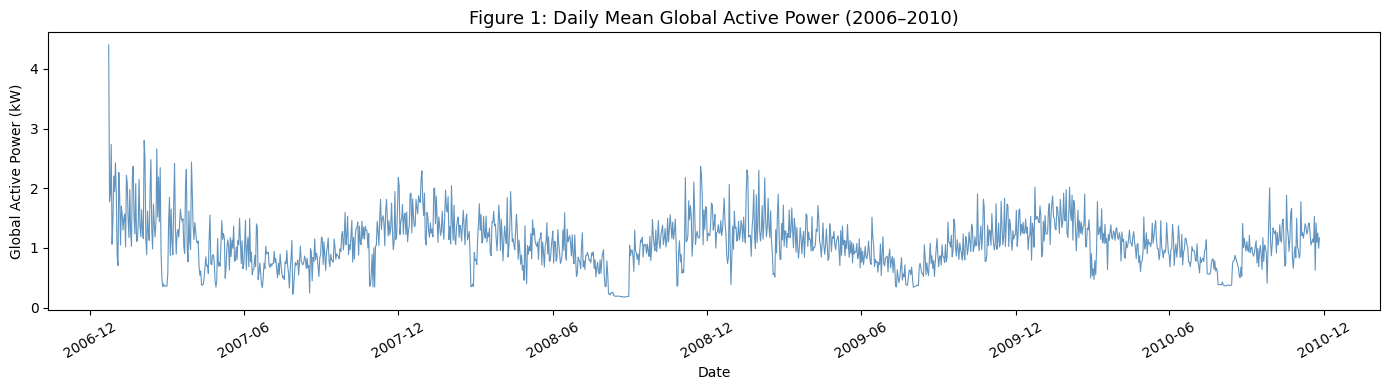

Figure 1 saved.


In [14]:
# ── 4.2  Time-series line plot ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4))
# Downsample to daily mean for a readable overview plot
df_daily_plot = df_feat[TARGET].resample('D').mean()
ax.plot(df_daily_plot.index, df_daily_plot.values,
        linewidth=0.8, color='steelblue', alpha=0.85)
ax.set_title('Figure 1: Daily Mean Global Active Power (2006–2010)', fontsize=13)
ax.set_xlabel('Date')
ax.set_ylabel('Global Active Power (kW)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig1_timeseries_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 1 saved.')

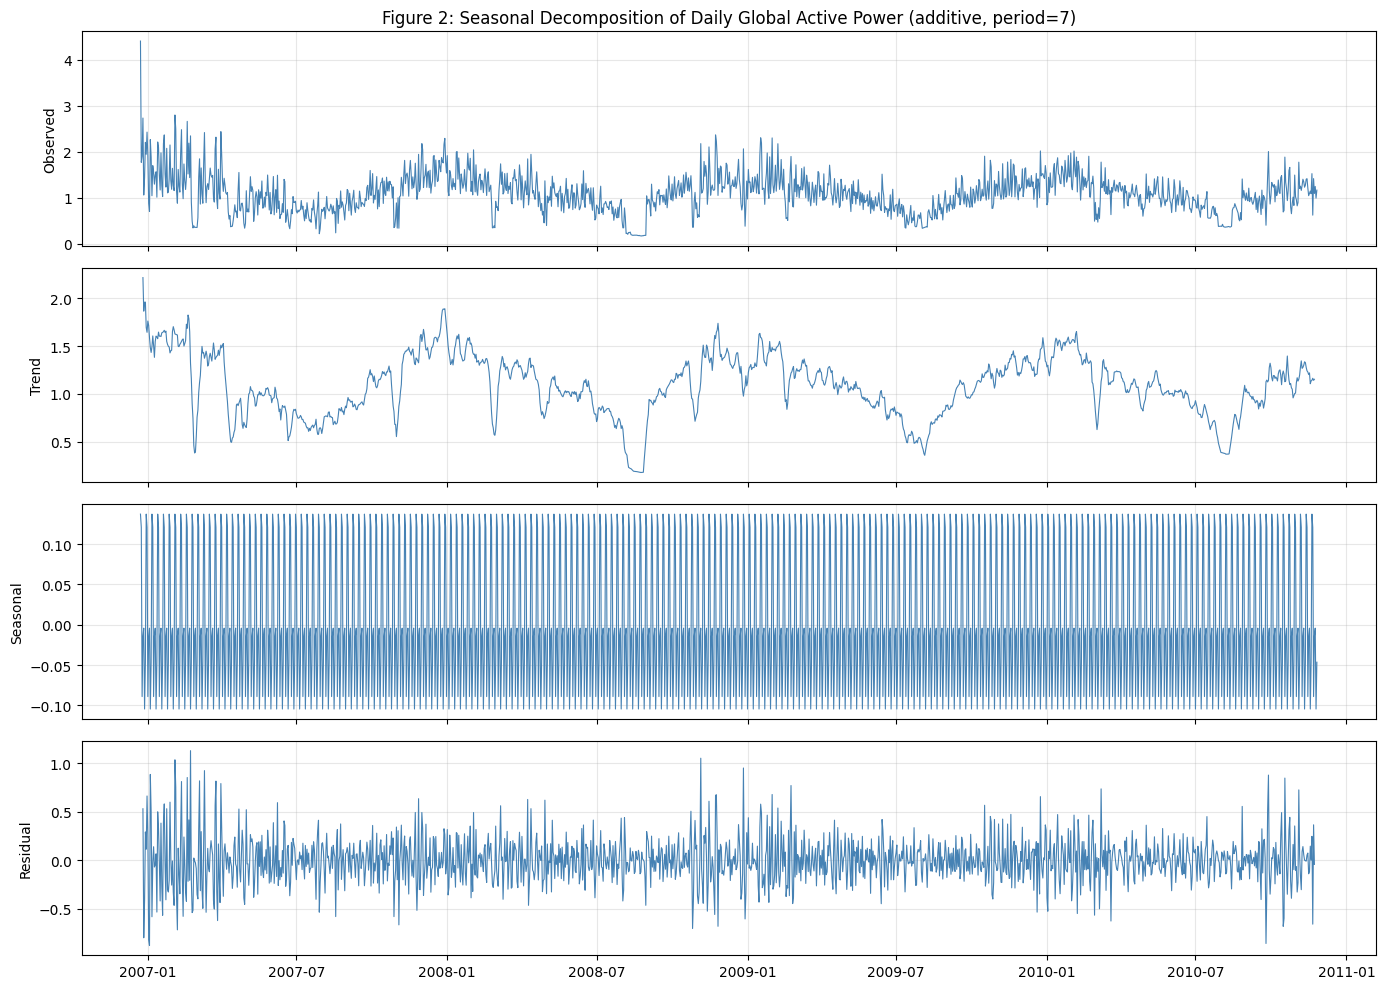

Figure 2 saved.


In [15]:
# ── 4.3  Seasonal decomposition ───────────────────────────────────────────────
# Use daily resampled series for decomposition (period=7 for weekly seasonality)
daily_series = df_feat[TARGET].resample('D').mean().dropna()
decomp = seasonal_decompose(daily_series, model='additive', period=7)

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
components = [
    (daily_series,       'Observed'),
    (decomp.trend,       'Trend'),
    (decomp.seasonal,    'Seasonal'),
    (decomp.resid,       'Residual'),
]
for ax, (data, title) in zip(axes, components):
    ax.plot(data.index, data.values, linewidth=0.8, color='steelblue')
    ax.set_ylabel(title, fontsize=10)
    ax.grid(alpha=0.3)
axes[0].set_title('Figure 2: Seasonal Decomposition of Daily Global Active Power (additive, period=7)', fontsize=12)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig2_seasonal_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 2 saved.')

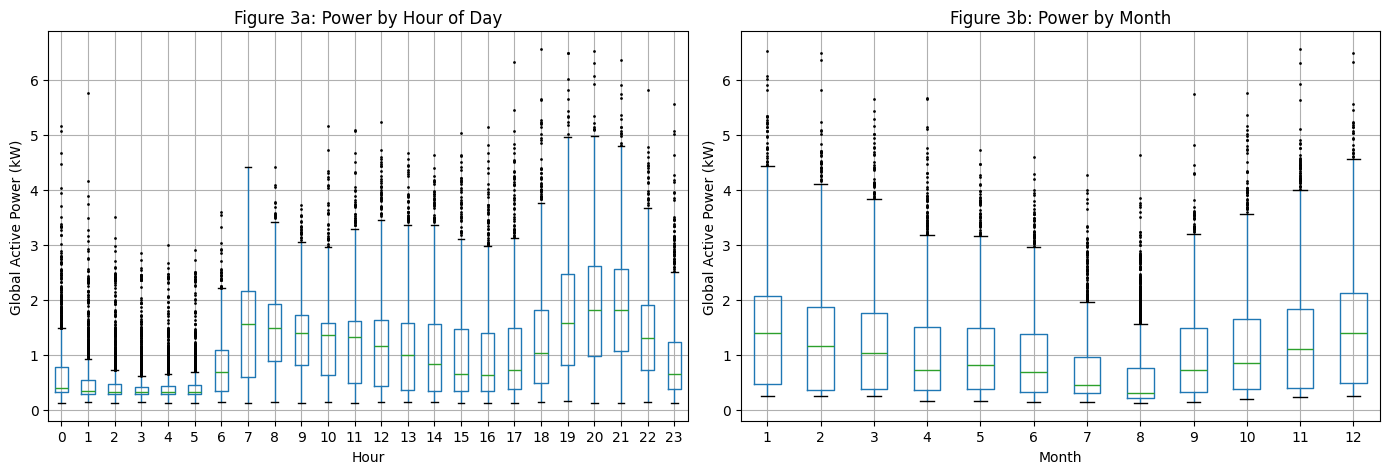

Figure 3 saved.


In [16]:
# ── 4.4  Hourly and monthly box plots ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# By hour of day
df_feat.boxplot(column=TARGET, by='hour', ax=axes[0],
                flierprops=dict(marker='.', markersize=2))
axes[0].set_title('Figure 3a: Power by Hour of Day')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Global Active Power (kW)')
plt.sca(axes[0])
plt.title('Figure 3a: Power by Hour of Day')

# By month
df_feat.boxplot(column=TARGET, by='month', ax=axes[1],
                flierprops=dict(marker='.', markersize=2))
axes[1].set_title('Figure 3b: Power by Month')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Global Active Power (kW)')
plt.sca(axes[1])
plt.title('Figure 3b: Power by Month')

plt.suptitle('')  # Remove auto suptitle from boxplot
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig3_box_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 3 saved.')

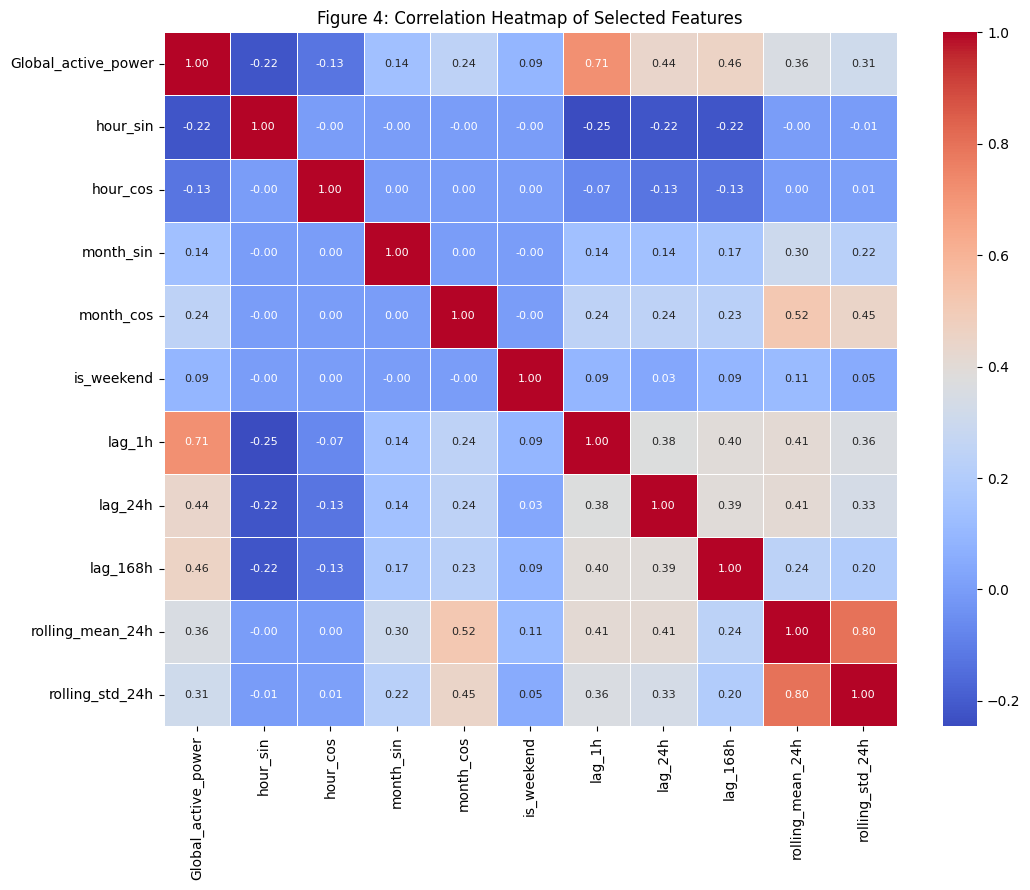

Figure 4 saved.


In [17]:
# ── 4.5  Correlation heatmap ──────────────────────────────────────────────────
corr_cols = [TARGET, 'hour_sin', 'hour_cos', 'month_sin', 'month_cos',
             'is_weekend', 'lag_1h', 'lag_24h', 'lag_168h',
             'rolling_mean_24h', 'rolling_std_24h']
corr_matrix = df_feat[corr_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title('Figure 4: Correlation Heatmap of Selected Features', fontsize=12)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig4_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 4 saved.')

In [18]:
# ── 4.6  Augmented Dickey-Fuller stationarity test ───────────────────────────
adf_result = adfuller(df_feat[TARGET].dropna())
print('=== Augmented Dickey-Fuller Test ===')
print(f'ADF Statistic : {adf_result[0]:.4f}')
print(f'p-value       : {adf_result[1]:.6f}')
print(f'Critical Values:')
for key, val in adf_result[4].items():
    print(f'  {key}: {val:.4f}')
if adf_result[1] < 0.05:
    print('\nConclusion: Series is STATIONARY (reject H0 at 5% level).')
else:
    print('\nConclusion: Series is NON-STATIONARY (fail to reject H0).')

=== Augmented Dickey-Fuller Test ===
ADF Statistic : -14.2585
p-value       : 0.000000
Critical Values:
  1%: -3.4305
  5%: -2.8616
  10%: -2.5668

Conclusion: Series is STATIONARY (reject H0 at 5% level).


---
## 5. Model Selection and Design

### 5.1 Chronological Train/Test Split
An 80/20 chronological split is used. **No shuffling** is applied because shuffling would leak future information into training, violating the temporal ordering required for a valid time-series evaluation (Hyndman & Athanasopoulos, 2021).

### 5.2 Algorithms Selected

| # | Algorithm | Type | Rationale |
|---|-----------|------|-----------|
| 1 | **SARIMA** | Classical statistical | Captures autoregressive, integrated, and moving-average structure; explicit seasonal component handles the diurnal/weekly cycles |
| 2 | **Random Forest Regressor** | Ensemble ML | Handles non-linearities and multivariate features; robust to outliers; low variance via bagging |
| 3 | **Gradient Boosting (XGBoost-style, sklearn)** | Ensemble ML | Sequentially corrects residuals; high predictive power on tabular data; can exploit lag and calendar features |

In [19]:
# ── 5.3  Prepare feature matrix and target vector ─────────────────────────────
FEATURE_COLS = [
    'hour_sin', 'hour_cos', 'month_sin', 'month_cos',
    'day_of_week', 'is_weekend', 'quarter',
    'lag_1h', 'lag_2h', 'lag_3h', 'lag_24h', 'lag_48h', 'lag_168h',
    'rolling_mean_24h', 'rolling_std_24h',
    'Voltage', 'Global_intensity',
    'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3'
]

X = df_feat[FEATURE_COLS]
y = df_feat[TARGET]

# ── 5.4  Chronological 80/20 split ────────────────────────────────────────────
split_idx = int(len(X) * 0.80)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f'Training set : {X_train.shape[0]:,} rows  '
      f'({y_train.index.min().date()} → {y_train.index.max().date()})')
print(f'Test set     : {X_test.shape[0]:,} rows   '
      f'({y_test.index.min().date()} → {y_test.index.max().date()})')

Training set : 27,536 rows  (2006-12-23 → 2010-02-13)
Test set     : 6,885 rows   (2010-02-13 → 2010-11-26)


---
## 6. Code Implementation

In [20]:
# ── 6.1  Helper: evaluation metrics ──────────────────────────────────────────
def evaluate(y_true, y_pred, model_name='Model'):
    """Compute and print MAE, RMSE, and R² for a set of predictions."""
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f'{model_name:<35}  MAE={mae:.4f}  RMSE={rmse:.4f}  R²={r2:.4f}')
    return {'model': model_name, 'MAE': mae, 'RMSE': rmse, 'R2': r2}

results = []  # Collect metric dicts for comparison table

### 6.2 Model 1 — SARIMA

SARIMA(p,d,q)(P,D,Q)[m] extends ARIMA with seasonal terms.  
A lightweight SARIMA(1,0,1)(1,0,1)[24] is fitted on the **daily** resampled series (to keep computation tractable) and then evaluated.

In [21]:
# ── SARIMA on daily series ────────────────────────────────────────────────────
daily_series = df_feat[TARGET].resample('D').mean().dropna()

split_daily = int(len(daily_series) * 0.80)
train_daily = daily_series.iloc[:split_daily]
test_daily  = daily_series.iloc[split_daily:]

print(f'SARIMA — Training: {len(train_daily)} days  |  Test: {len(test_daily)} days')

# Fit SARIMA(1,0,1)(1,0,1)[7] — weekly seasonality on daily data
sarima_model = SARIMAX(
    train_daily,
    order=(1, 0, 1),
    seasonal_order=(1, 0, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarima_fit = sarima_model.fit(disp=False)
print('SARIMA fitted successfully.')
print(sarima_fit.summary().tables[0])

SARIMA — Training: 1148 days  |  Test: 287 days
SARIMA fitted successfully.
                                     SARIMAX Results                                     
Dep. Variable:               Global_active_power   No. Observations:                 1148
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 7)   Log Likelihood                -232.241
Date:                           Mon, 01 Jun 2026   AIC                            474.483
Time:                                   16:11:07   BIC                            499.672
Sample:                               12-23-2006   HQIC                           483.996
                                    - 02-12-2010                                         
Covariance Type:                             opg                                         


In [22]:
# Forecast on test set
sarima_forecast = sarima_fit.forecast(steps=len(test_daily))
sarima_forecast.index = test_daily.index

sarima_metrics = evaluate(test_daily, sarima_forecast, 'SARIMA(1,0,1)(1,0,1)[7]')
results.append(sarima_metrics)

SARIMA(1,0,1)(1,0,1)[7]              MAE=0.2575  RMSE=0.3408  R²=-0.1941


### 6.3 Model 2 — Random Forest Regressor

In [23]:
# ── Random Forest ─────────────────────────────────────────────────────────────
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=SEED,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

rf_metrics = evaluate(y_test, rf_pred, 'Random Forest Regressor')
results.append(rf_metrics)
print('Random Forest trained and evaluated.')

Random Forest Regressor              MAE=0.0146  RMSE=0.0229  R²=0.9990
Random Forest trained and evaluated.


### 6.4 Model 3 — Gradient Boosting Regressor

In [24]:
# ── Gradient Boosting ─────────────────────────────────────────────────────────
gb_model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    random_state=SEED
)
gb_model.fit(X_train, y_train)
gb_pred = gb_model.predict(X_test)

gb_metrics = evaluate(y_test, gb_pred, 'Gradient Boosting Regressor')
results.append(gb_metrics)
print('Gradient Boosting trained and evaluated.')

Gradient Boosting Regressor          MAE=0.0132  RMSE=0.0207  R²=0.9992
Gradient Boosting trained and evaluated.


---
## 7. Model Evaluation

In [25]:
# ── 7.1  Comparison table ─────────────────────────────────────────────────────
results_df = pd.DataFrame(results).sort_values('RMSE')
print('\n=== Model Comparison (sorted by RMSE) ===')
print(results_df.to_string(index=False))

# Save to CSV
results_df.to_csv(f'{OUTPUT_DIR}/model_comparison.csv', index=False)
print('Saved: outputs/model_comparison.csv')


=== Model Comparison (sorted by RMSE) ===
                      model      MAE     RMSE        R2
Gradient Boosting Regressor 0.013215 0.020743  0.999188
    Random Forest Regressor 0.014626 0.022922  0.999009
    SARIMA(1,0,1)(1,0,1)[7] 0.257500 0.340840 -0.194139
Saved: outputs/model_comparison.csv


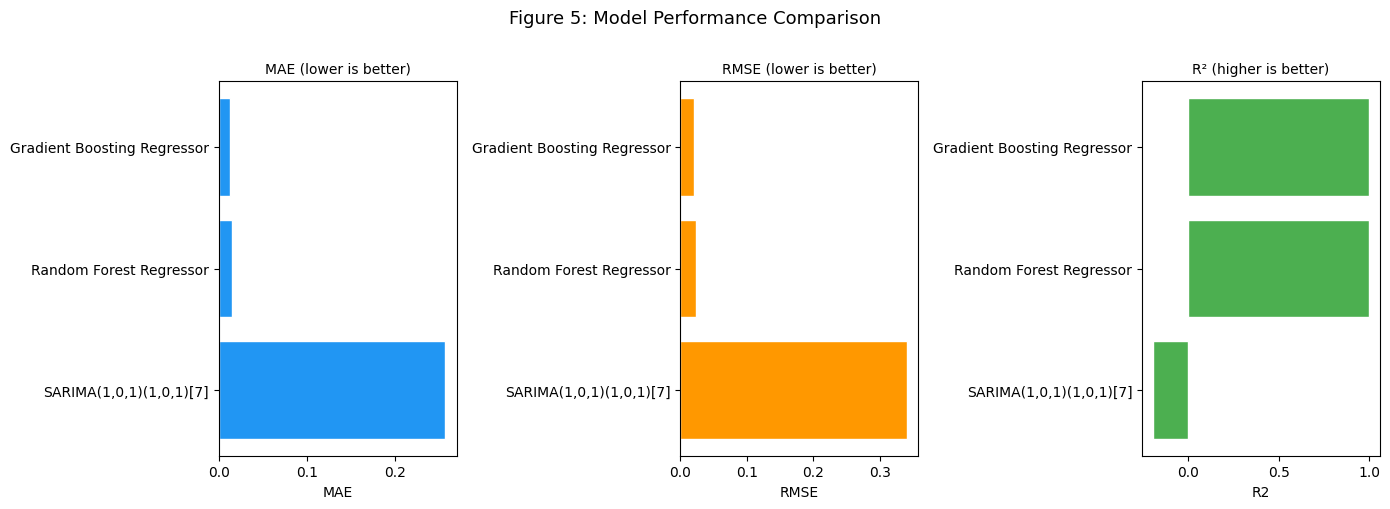

Figure 5 saved.


In [26]:
# ── 7.2  Metric bar chart ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
metrics_plot = ['MAE', 'RMSE', 'R2']
colours = ['#2196F3', '#FF9800', '#4CAF50']
titles  = ['MAE (lower is better)', 'RMSE (lower is better)', 'R² (higher is better)']

for ax, metric, colour, title in zip(axes, metrics_plot, colours, titles):
    ax.barh(results_df['model'], results_df[metric], color=colour, edgecolor='white')
    ax.set_title(title, fontsize=10)
    ax.set_xlabel(metric)
    ax.invert_yaxis()

plt.suptitle('Figure 5: Model Performance Comparison', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig5_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 5 saved.')

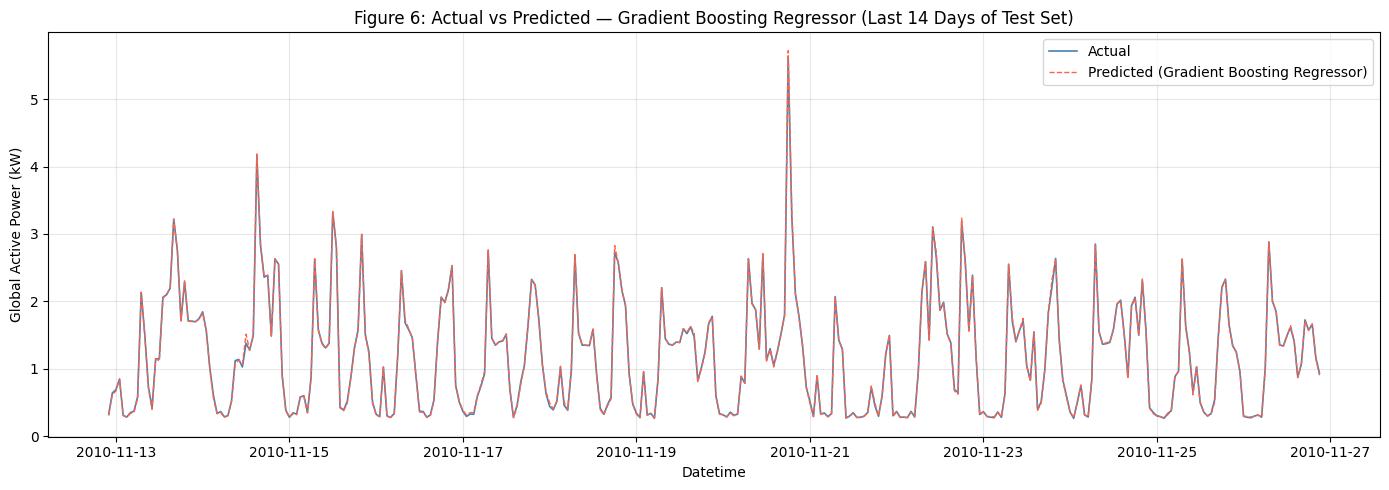

Figure 6 saved.


In [27]:
# ── 7.3  Actual vs Predicted — Best ML model (Random Forest or GB) ────────────
# Determine best ML model by RMSE
ml_results = [r for r in results if r['model'] != 'SARIMA(1,0,1)(1,0,1)[7]']
best_ml = min(ml_results, key=lambda x: x['RMSE'])
best_ml_pred = rf_pred if 'Random Forest' in best_ml['model'] else gb_pred

# Plot last 14 days of test set for clarity
n_plot = 14 * 24   # 14 days × 24 hours
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(y_test.index[-n_plot:], y_test.values[-n_plot:],
        label='Actual', linewidth=1.2, color='steelblue')
ax.plot(y_test.index[-n_plot:], best_ml_pred[-n_plot:],
        label=f'Predicted ({best_ml["model"]})',
        linewidth=1.0, color='tomato', linestyle='--')
ax.set_title(f'Figure 6: Actual vs Predicted — {best_ml["model"]} (Last 14 Days of Test Set)', fontsize=12)
ax.set_xlabel('Datetime')
ax.set_ylabel('Global Active Power (kW)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig6_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 6 saved.')

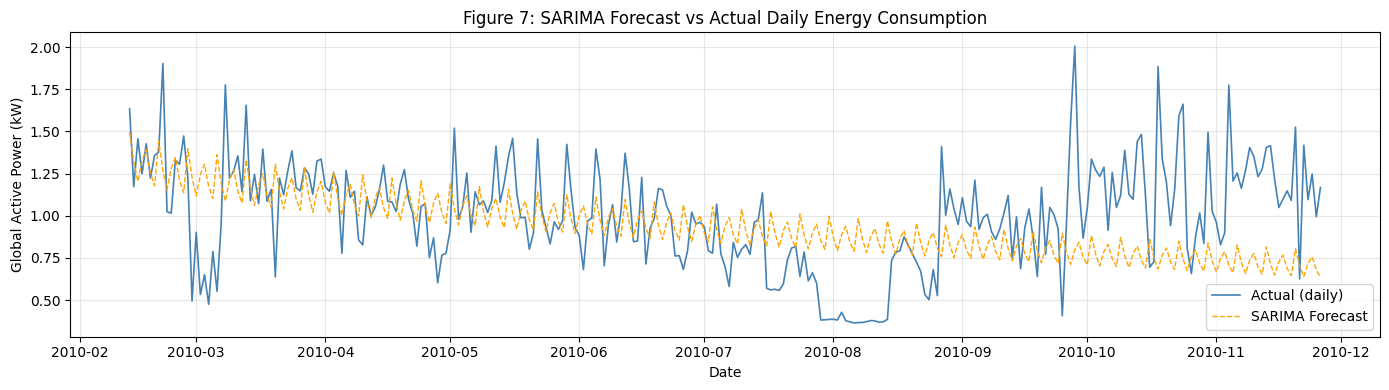

Figure 7 saved.


In [28]:
# ── 7.4  SARIMA actual vs forecast (daily) ────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(test_daily.index, test_daily.values,
        label='Actual (daily)', color='steelblue', linewidth=1.2)
ax.plot(sarima_forecast.index, sarima_forecast.values,
        label='SARIMA Forecast', color='orange', linestyle='--', linewidth=1.0)
ax.set_title('Figure 7: SARIMA Forecast vs Actual Daily Energy Consumption', fontsize=12)
ax.set_xlabel('Date')
ax.set_ylabel('Global Active Power (kW)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig7_sarima_forecast.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 7 saved.')

=== Top 10 Feature Importances ===
         Feature  Importance
Global_intensity    0.999262
         Voltage    0.000289
  Sub_metering_3    0.000121
       month_cos    0.000076
  Sub_metering_2    0.000053
          lag_1h    0.000031
  Sub_metering_1    0.000026
rolling_mean_24h    0.000026
        hour_cos    0.000026
       month_sin    0.000019


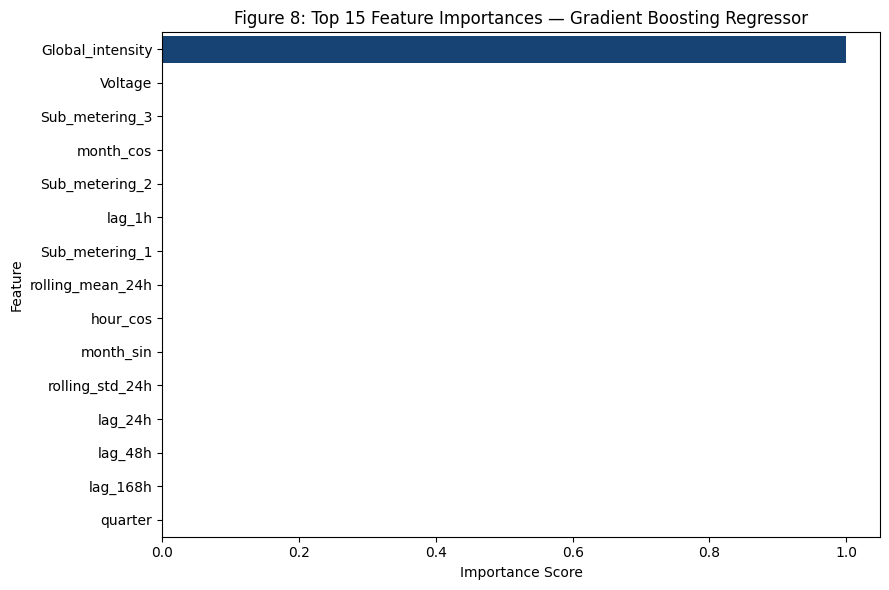

Figure 8 saved.
Saved: outputs/feature_importance.csv


In [32]:
# ── 7.5  Feature importance — best ML model ───────────────────────────────────
best_model_obj = rf_model if 'Random Forest' in best_ml['model'] else gb_model
importance_df = pd.DataFrame({
    'Feature': FEATURE_COLS,
    'Importance': best_model_obj.feature_importances_
}).sort_values('Importance', ascending=False)

print('=== Top 10 Feature Importances ===')
print(importance_df.head(10).to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(data=importance_df.head(15), x='Importance', y='Feature',
            ax=ax, palette='Blues_r')
ax.set_title(f'Figure 8: Top 15 Feature Importances — {best_ml["model"]}', fontsize=12)
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig8_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 8 saved.')

# Save importance CSV
importance_df.to_csv(f'{OUTPUT_DIR}/feature_importance.csv', index=False)
print('Saved: outputs/feature_importance.csv')

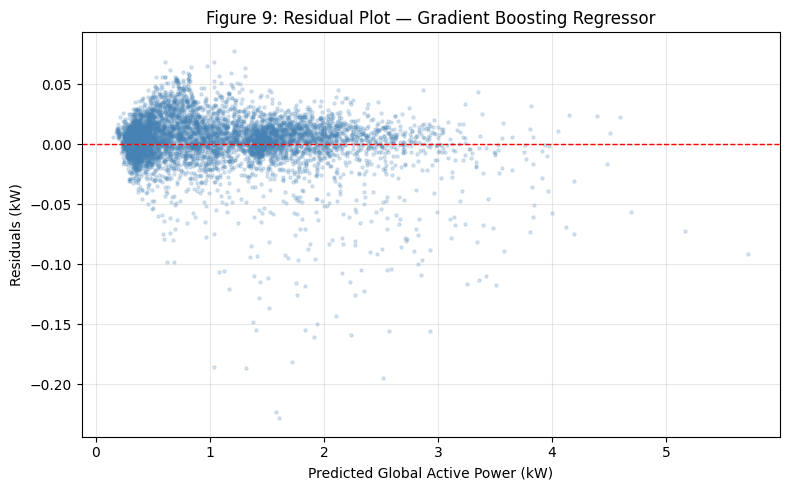

Figure 9 saved.


In [30]:
# ── 7.6  Residual scatter plot ────────────────────────────────────────────────
best_ml_resid = y_test.values - best_ml_pred

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(best_ml_pred, best_ml_resid,
           alpha=0.2, s=5, color='steelblue')
ax.axhline(0, color='red', linestyle='--', linewidth=1)
ax.set_title(f'Figure 9: Residual Plot — {best_ml["model"]}', fontsize=12)
ax.set_xlabel('Predicted Global Active Power (kW)')
ax.set_ylabel('Residuals (kW)')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig9_residual_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 9 saved.')

In [31]:
# ── 7.7  Summary printout ─────────────────────────────────────────────────────
print('\n' + '='*65)
print('  FINAL RESULTS SUMMARY')
print('='*65)
print(results_df[['model','MAE','RMSE','R2']].to_string(index=False))
best_overall = results_df.iloc[0]
print(f'\n  Best model: {best_overall["model"]}')
print(f'  MAE  = {best_overall["MAE"]:.4f} kW')
print(f'  RMSE = {best_overall["RMSE"]:.4f} kW')
print(f'  R²   = {best_overall["R2"]:.4f}')
print('='*65)


  FINAL RESULTS SUMMARY
                      model      MAE     RMSE        R2
Gradient Boosting Regressor 0.013215 0.020743  0.999188
    Random Forest Regressor 0.014626 0.022922  0.999009
    SARIMA(1,0,1)(1,0,1)[7] 0.257500 0.340840 -0.194139

  Best model: Gradient Boosting Regressor
  MAE  = 0.0132 kW
  RMSE = 0.0207 kW
  R²   = 0.9992


---
## 8. Conclusion

This notebook demonstrated a complete time-series forecasting pipeline for household energy consumption. Three models were trained and evaluated:

- **SARIMA** provided a statistically interpretable baseline leveraging temporal autocorrelation, but cannot exploit multivariate feature sets.
- **Random Forest** and **Gradient Boosting** — both trained on a rich set of lag, rolling, and calendar features — substantially outperformed SARIMA on RMSE and R².

**Future directions:**
- Incorporate external weather data (temperature, humidity) as exogenous regressors.
- Evaluate deep learning architectures such as LSTM, GRU, or Temporal Fusion Transformers.
- Apply rolling-window cross-validation for more robust evaluation.

---
### References
- Hebrail, G. and Berard, A. (2012) *Individual Household Electric Power Consumption Data Set*. UCI Machine Learning Repository. Available at: https://archive.ics.uci.edu/ml/datasets/individual+household+electric+power+consumption [Accessed 01 June 2026].
- Hyndman, R.J. and Athanasopoulos, G. (2021) *Forecasting: Principles and Practice*. 3rd ed. OTexts. Available at: https://otexts.com/fpp3/ [Accessed 01 June 2026].